***the problem statement is predict the student mark whether using machine learning model***


In [2]:
#import libraries
import numpy as np #using data handling
import pandas as pd #read the dataset and data handling
import matplotlib.pyplot as plt #visuavalize the data
import seaborn as sns #advanced visuavalization
from sklearn.linear_model import LinearRegression #ml algorithm regression
from sklearn.model_selection import train_test_split #splitting dataset
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score #predict the accuracy score

**load dataset**

In [3]:
stud_mark=pd.read_csv('data.csv')
stud_mark.head()

,1st,2nd,3rd,4th,5th,College Code,Gender,Roll,Roll no.,Subject Code
0,8.11,7.68,7.11,7.43,8.18,115,Female,NaN,17020.0,16
1,6.48,5.90,4.15,4.29,4.96,115,Male,NaN,17021.0,16
2,8.41,8.24,7.52,8.25,7.75,115,Female,NaN,17022.0,16
3,7.33,6.83,6.33,6.79,6.89,115,Male,NaN,17023.0,16
4,7.89,7.34,7.22,7.32,7.46,115,Male,NaN,17024.0,16


In [43]:
stud_mark.shape


(165, 10)

In [41]:
#drop columns
stud_mark.drop(columns=['Roll','Roll no.','College Code','Subject Code'])


,1st,2nd,3rd,4th,5th,Gender
0,8.11,7.68,7.11,7.43,8.18,1
2,8.41,8.24,7.52,8.25,7.75,1
3,7.33,6.83,6.33,6.79,6.89,3
4,7.89,7.34,7.22,7.32,7.46,3
5,7.33,6.72,6.48,6.50,7.39,3
...,...,...,...,...,...,...
173,7.48,7.55,7.67,7.39,8.65,0
174,7.30,6.41,6.59,7.11,7.38,2
175,6.30,6.28,5.89,5.71,6.50,2
176,7.04,7.10,6.81,7.00,6.92,2


In [10]:
stud_mark.isnull().sum()


1st               2
2nd               4
3rd               2
4th               5
5th               6
College Code      0
Gender            1
Roll             46
Roll no.        132
Subject Code      0
dtype: int64

In [11]:
stud_mark['5th'].value_counts()

5th
7.00    6
8.21    6
6.75    5
6.18    4
8.36    4
       ..
4.77    1
5.81    1
7.04    1
6.50    1
6.92    1
Name: count, Length: 100, dtype: int64

In [12]:
#using fillna method for all columns numeric_only function using
stud_mark=stud_mark.fillna(stud_mark.mean(numeric_only=True))


In [13]:
#using mode for categorical data only
stud_mark['Gender']=stud_mark['Gender'].fillna(stud_mark['Gender'].mode()[0])
stud_mark['Gender'].isnull().sum()

np.int64(0)

In [44]:
#stud_mark.isnull().sum()
#print(stud_mark.info()) information of the dataset
print(stud_mark.describe()) #statistical summmary


              1st         2nd         3rd         4th         5th  \
count  165.000000  165.000000  165.000000  165.000000  165.000000   
mean     7.119623    7.008041    6.733106    7.108383    7.549653   
std      0.750094    0.796762    0.746360    0.945620    0.917049   
min      5.110000    5.480000    4.590000    4.930000    5.080000   
25%      6.590000    6.410000    6.300000    6.500000    6.930000   
50%      7.110000    6.900000    6.750000    7.140000    7.610000   
75%      7.590000    7.660000    7.260000    7.860000    8.210000   
max      9.150000    8.860000    8.370000    9.250000    9.390000   

       College Code      Gender          Roll      Roll no.  Subject Code  
count    165.000000  165.000000    165.000000    165.000000    165.000000  
mean     153.969697    2.230303  17040.743434  17042.593939     18.472727  
std       49.030531    0.859837     11.824405      6.628327      4.868470  
min      115.000000    0.000000  17017.000000  17020.000000     16.000000 

<Axes: xlabel='3rd', ylabel='Count'>

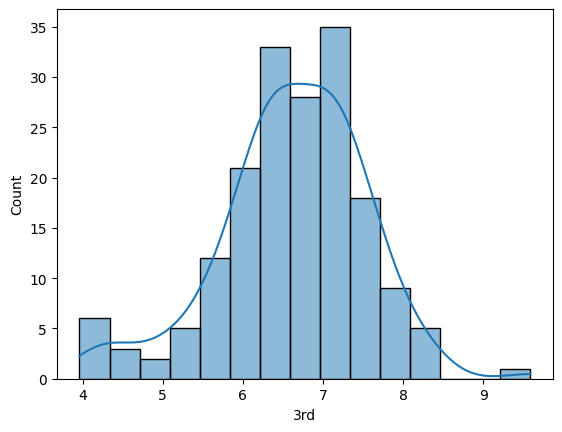

In [15]:
#exploratory data analysis
sns.histplot(stud_mark['3rd'],kde=True)

<Axes: ylabel='5th'>

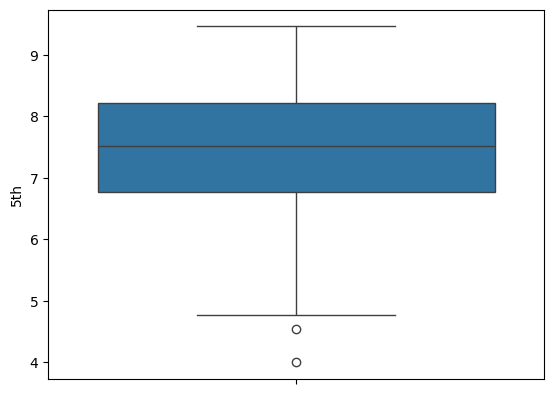

In [20]:
#check outliers
sns.boxplot(stud_mark['5th']) #outliers will be find out better option these are remove only

In [21]:
#remove outliers
cols = ['1st', '2nd', '3rd','5th']

for col in cols:
    Q1 = stud_mark[col].quantile(0.25)
    Q3 = stud_mark[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    stud_mark = stud_mark[
        (stud_mark[col] >= lower) & 
        (stud_mark[col] <= upper)
    ]

print(stud_mark.shape)

(165, 10)


<Axes: ylabel='5th'>

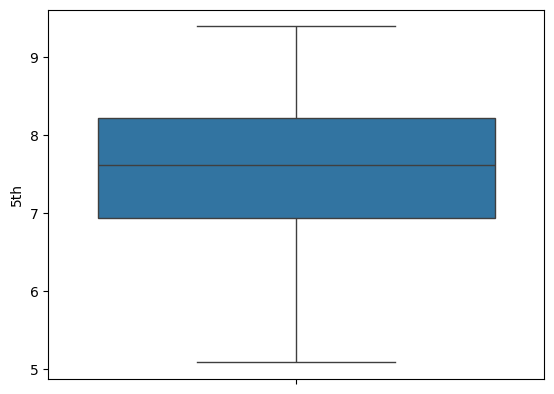

In [29]:
sns.boxplot(stud_mark['5th'])

C:\Users\Vishwa\AppData\Local\Temp\ipykernel_19856\4263786254.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


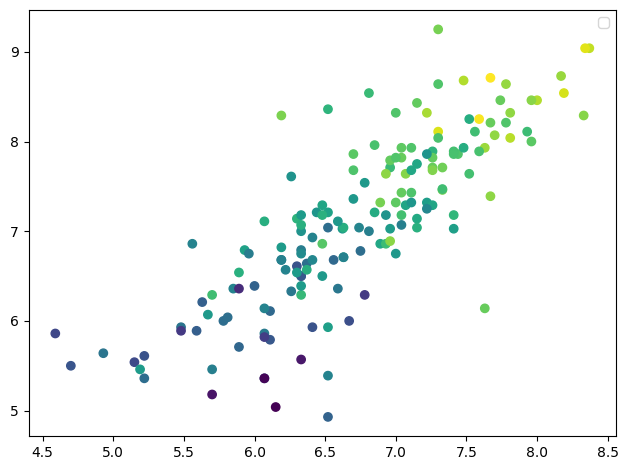

In [25]:
#scatter plot
plt.scatter(stud_mark['3rd'],stud_mark['4th'],c=stud_mark['5th'])
plt.tight_layout()
plt.legend()

<Axes: >

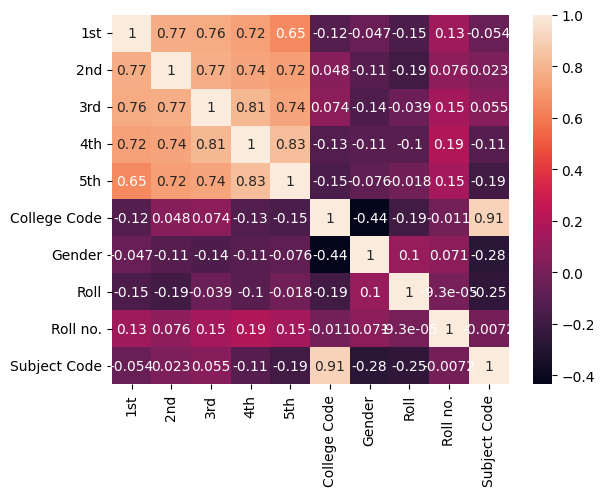

In [32]:
sns.heatmap(stud_mark.corr(),annot=True)

In [31]:
#encoding method
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
stud_mark['Gender']=le.fit_transform(stud_mark['Gender'])
stud_mark.head()

,1st,2nd,3rd,4th,5th,College Code,Gender,Roll,Roll no.,Subject Code
0,8.11,7.68,7.11,7.43,8.18,115,1,17040.666667,17020.0,16
2,8.41,8.24,7.52,8.25,7.75,115,1,17040.666667,17022.0,16
3,7.33,6.83,6.33,6.79,6.89,115,3,17040.666667,17023.0,16
4,7.89,7.34,7.22,7.32,7.46,115,3,17040.666667,17024.0,16
5,7.33,6.72,6.48,6.50,7.39,115,3,17040.666667,17025.0,16


In [33]:
stud_mark['Gender'].value_counts()

Gender
3    74
2    65
1    16
0    10
Name: count, dtype: int64

In [34]:
#splitting features and labels
x=stud_mark.drop(columns=['5th'])
x

,1st,2nd,3rd,4th,College Code,Gender,Roll,Roll no.,Subject Code
0,8.11,7.68,7.11,7.43,115,1,17040.666667,17020.0,16
2,8.41,8.24,7.52,8.25,115,1,17040.666667,17022.0,16
3,7.33,6.83,6.33,6.79,115,3,17040.666667,17023.0,16
4,7.89,7.34,7.22,7.32,115,3,17040.666667,17024.0,16
5,7.33,6.72,6.48,6.50,115,3,17040.666667,17025.0,16
...,...,...,...,...,...,...,...,...,...
173,7.48,7.55,7.67,7.39,241,0,17048.000000,17042.5,28
174,7.30,6.41,6.59,7.11,241,2,17049.000000,17042.5,28
175,6.30,6.28,5.89,5.71,241,2,17050.000000,17042.5,28
176,7.04,7.10,6.81,7.00,241,2,17051.000000,17042.5,28


In [35]:
y=stud_mark.iloc[:,-6]
y

0      8.18
2      7.75
3      6.89
4      7.46
5      7.39
       ... 
173    8.65
174    7.38
175    6.50
176    6.92
177    7.00
Name: 5th, Length: 165, dtype: float64

In [36]:
#splitting train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

print(x_train)


      1st   2nd   3rd   4th  College Code  Gender          Roll  Roll no.  \
128  6.74  6.72  7.04  7.93           116       3  17053.000000   17042.5   
101  6.85  7.41  7.41  7.86           116       3  17026.000000   17042.5   
145  7.07  7.66  7.22  7.86           241       0  17020.000000   17042.5   
38   7.59  7.38  7.30  8.64           115       3  17040.666667   17058.0   
89   7.37  7.93  7.07  7.64           165       2  17064.000000   17042.5   
..    ...   ...   ...   ...           ...     ...           ...       ...   
78   7.11  7.07  6.07  5.86           165       2  17053.000000   17042.5   
115  9.15  8.86  8.34  9.04           116       3  17040.000000   17042.5   
16   6.96  6.14  6.93  7.18           115       3  17040.666667   17036.0   
99   5.93  5.86  4.70  5.50           116       3  17024.000000   17042.5   
111  7.89  8.72  8.19  8.54           116       3  17036.000000   17042.5   

     Subject Code  
128            16  
101            16  
145            

In [37]:
#random forest algorithm using
from sklearn.ensemble import RandomForestRegressor
RFR=RandomForestRegressor()
RFR.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
#predict test data
y_pred=RFR.predict(x_test)
print(y_pred)

[6.37485581 6.74095116 8.8355     7.51970698 7.96105116 8.5046
 7.97922558 8.8488     7.41995116 8.414      8.5262     6.57688372
 6.61927674 7.76660233 7.1359     8.232      7.28087674 8.1722
 7.09635116 8.1798     8.286      6.5353     6.9052     8.1053
 8.3538     7.54535116 8.4257     7.90067674 8.5276     7.31053023
 6.62583023 7.43392558 7.96075116 7.88015349 7.4112     6.43102558
 8.7306     8.05       6.56185581 7.26063256 8.2068     5.98240465]


***model evaluation***

In [39]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

0.3618455703211509
0.24845919897409136
0.7780696775360169


In [45]:
import pickle
pickle.dump(RFR,open('model.pkl','wb'))
print('model saved!')

model saved!


In [46]:
model=pickle.load(open('model.pkl','rb'))
print(model)

RandomForestRegressor()
